In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch
import sys
from scipy import stats

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/')
from simulate_ALBF_calibration_eval import ALBFCalibrationAnalysis

In [2]:
# Main path set up
main_path="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis"

# Choose which simulation directory to analyze 
dir_analyze="analysis_20250122_161944_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_150_LearnedConc_Inits_2_NoCellType_Random_31553"

# Set up the path to the simulation directory
sim_dir=os.path.join(main_path,dir_analyze)

# Print the names of the files in the simulation directory
files = os.listdir(sim_dir)
print(files)

['clustermap.png', 'losses.png', 'assignment_correlations.png', 'est_deltapsi_vs_difference.png', 'pi_barplot.png', 'nmf_clustermap.png', 'nmf_umap.png.pdf', 'ALBF_scores.csv', 'random_init_65165_loss_curve.png', 'albf_vs_difference.png', 'cell_type_psi_df.csv', 'final_results.csv', 'ALBF_report.txt', 'umap.png.pdf', 'roc_curve.png', 'est_deltapsi_vs_difference.pdf', 'random_init_67861_loss_curve.png', 'parameters.json', 'precision_recall_curve.png', 'analysis_report.txt', 'precision_recall_curve.pdf', 'ALBF_score_distribution.png']


In [3]:
# Original PSI_df from simulation
PSI_df = pd.read_csv(os.path.join(sim_dir, "cell_type_psi_df.csv"))

In [4]:
PSI_df[PSI_df["true_label"] == "negative"]

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
0,0,0.121480,0.121480,0,chr10_100080130_100080856_+,negative,35178,0.0,negative
1,1,0.757040,0.757040,1,chr10_100080130_100087346_+,negative,35178,0.0,negative
2,2,0.121480,0.121480,2,chr10_100080940_100087346_+,negative,35178,0.0,negative
3,0,0.000008,0.000008,3,chr10_100478022_100485050_-,negative,37286,0.0,negative
4,1,0.999983,0.999983,4,chr10_100478022_100487161_-,negative,37286,0.0,negative
...,...,...,...,...,...,...,...,...,...
15886,1,0.054628,0.054628,15886,chrY_1280439_1284321_-,negative,62124,0.0,negative
15887,2,0.472686,0.472686,15887,chrY_1282948_1284321_-,negative,62124,0.0,negative
15891,0,0.460526,0.460526,15891,chrY_900613_910447_+,negative,62095,0.0,negative
15892,1,0.078949,0.078949,15892,chrY_910586_910656_+,negative,62095,0.0,negative


In [5]:
PSI_df.sample_label.value_counts()

sample_label
negative    7947
positive    7947
Name: count, dtype: int64

In [6]:
# let's load the final_results.csv file 
albf_scores = pd.read_csv(os.path.join(sim_dir, "ALBF_scores.csv"))
# rename the first two columns to be sim_psi_1 and sim_psi_2
albf_scores = albf_scores.rename(columns={"0": "latent_psi_1", "1": "latent_psi_2"})
albf_scores.head()

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
0,0.121894,0.117083,0,0.017864,0.0,negative,35178,0,0.004810,0
1,0.760747,0.755083,1,0.003727,0.0,negative,35178,0,0.005664,0
2,0.124974,0.122090,2,0.002487,0.0,negative,35178,0,0.002884,0
3,0.000749,0.000648,3,0.001343,0.0,negative,37286,0,0.000100,0
4,0.999255,0.999548,4,0.004787,0.0,negative,37286,0,0.000293,0


In [7]:
albf_scores[albf_scores["true_label"] == "positive"].sort_values(by="ALBF", ascending=False)

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
12007,0.001210,0.825298,12007,351.720500,0.811507,positive,21944,1,0.824088,1
14167,0.197666,0.999267,14167,346.316100,0.793683,positive,28220,1,0.801601,1
14494,0.009873,0.994512,14494,290.219000,0.970719,positive,31389,1,0.984639,1
10138,0.004016,0.906193,10138,270.938870,0.883829,positive,14906,1,0.902177,1
5260,0.998235,0.244305,5260,269.340640,0.742612,positive,56192,1,0.753930,1
...,...,...,...,...,...,...,...,...,...,...
6618,0.107951,0.107093,6618,0.000870,0.004271,positive,109,1,0.000858,0
2345,0.337619,0.343613,2345,0.000638,0.024718,positive,44551,1,0.005994,0
10200,0.415171,0.411618,10200,0.000297,0.007478,positive,13010,1,0.003554,0
13769,0.213856,0.218010,13769,0.000215,0.003699,positive,28212,1,0.004154,0


In [8]:
albf_scores[albf_scores["true_label"] == "negative"].sort_values(by="ALBF", ascending=False)

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
9976,0.000512,0.001468,9976,4.345032,0.0,negative,13976,0,0.000956,1
7341,0.001468,0.000506,7341,2.292175,0.0,negative,1676,0,0.000963,1
6862,0.000313,0.002078,6862,1.819946,0.0,negative,865,0,0.001765,1
6860,0.000869,0.000394,6860,1.694458,0.0,negative,865,0,0.000475,1
12800,0.000578,0.001223,12800,0.823364,0.0,negative,26609,0,0.000645,1
...,...,...,...,...,...,...,...,...,...,...
8491,0.926695,0.930522,8491,0.000000,0.0,negative,6281,0,0.003827,0
14120,0.214210,0.212561,14120,0.000000,0.0,negative,31094,0,0.001649,0
7090,0.991469,0.990958,7090,-0.000004,0.0,negative,2292,0,0.000511,0
3799,0.135526,0.136620,3799,-0.000008,0.0,negative,50291,0,0.001094,0


In [9]:
def analyze_null_albf(df):
    """
    Analyze ALBF distribution for negative junctions
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'ALBF' and 'true_label' columns
    
    Returns
    -------
    dict
        Dictionary containing null distribution parameters
    """
    # Get ALBF values for negative junctions
    null_albf = df[df['true_label'] == 'negative']['ALBF']
    
    # Fit normal distribution to null ALBFs
    mu, std = stats.norm.fit(null_albf)
    
    # Test for normality
    _, norm_pval = stats.normaltest(null_albf)
    
    # Create visualization
    plt.figure(figsize=(10, 6))
    
    # Plot histogram of null ALBF values
    sns.histplot(null_albf, bins=30, color='blue', alpha=0.5, label='Observed')
    
    # Plot fitted normal distribution
    x = np.linspace(null_albf.min(), null_albf.max(), 100)
    plt.plot(x, stats.norm.pdf(x, mu, std) * len(null_albf) * (null_albf.max() - null_albf.min()) / 30,
             'r-', label='Fitted Normal')
    
    plt.title(f'Distribution of ALBF Values for Negative Junctions\nμ={mu:.2f}, σ={std:.2f}, p={norm_pval:.2e}')
    plt.xlabel('ALBF')
    plt.ylabel('Count')
    plt.legend()
    
    # Calculate percentiles for potential thresholds
    percentiles = [90, 95, 99]
    thresholds = np.percentile(null_albf, percentiles)
    
    return {
        'mu': mu,
        'std': std,
        'normality_pvalue': norm_pval,
        'thresholds': dict(zip(percentiles, thresholds))
    }

In [10]:
PSI_df[PSI_df["sample_label"] == "positive"]["difference"].min()

0.00040104985

<Axes: >

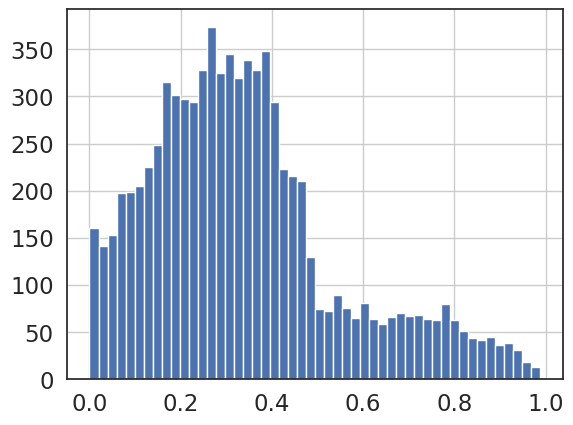

In [11]:
PSI_df[PSI_df["sample_label"] == "positive"]["difference"].hist(bins=50)

In [12]:
albf_scores.sort_values(by=["true_label", "ALBF"], ascending=[True, False], inplace=True)
albf_scores

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
9976,0.000512,0.001468,9976,4.345032,0.000000,negative,13976,0,0.000956,1
7341,0.001468,0.000506,7341,2.292175,0.000000,negative,1676,0,0.000963,1
6862,0.000313,0.002078,6862,1.819946,0.000000,negative,865,0,0.001765,1
6860,0.000869,0.000394,6860,1.694458,0.000000,negative,865,0,0.000475,1
12800,0.000578,0.001223,12800,0.823364,0.000000,negative,26609,0,0.000645,1
...,...,...,...,...,...,...,...,...,...,...
6618,0.107951,0.107093,6618,0.000870,0.004271,positive,109,1,0.000858,0
2345,0.337619,0.343613,2345,0.000638,0.024718,positive,44551,1,0.005994,0
10200,0.415171,0.411618,10200,0.000297,0.007478,positive,13010,1,0.003554,0
13769,0.213856,0.218010,13769,0.000215,0.003699,positive,28212,1,0.004154,0


In [13]:
# get range of ALBF scores
albf_scores["ALBF"].min(), albf_scores["ALBF"].max()

(-1.5258789e-05, 351.7205)

In [14]:
albf_scores[albf_scores["true_label"] == "negative"].sort_values(by="delta_est", ascending=False).head(100)

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
6799,0.696399,0.501656,6799,0.353326,0.0,negative,1867,0,0.194743,1
6629,0.334277,0.528191,6629,0.266022,0.0,negative,1888,0,0.193914,1
6798,0.117825,0.273434,6798,0.290605,0.0,negative,1867,0,0.155609,1
6848,0.394063,0.522585,6848,0.070893,0.0,negative,3170,0,0.128522,0
6800,0.154714,0.277956,6800,0.224299,0.0,negative,1867,0,0.123242,1
...,...,...,...,...,...,...,...,...,...,...
3154,0.183041,0.225109,3154,0.019056,0.0,negative,48292,0,0.042068,0
14252,0.377087,0.335155,14252,0.040163,0.0,negative,29579,0,0.041932,0
7010,0.136054,0.177249,7010,0.090868,0.0,negative,3551,0,0.041195,0
3875,0.525673,0.484951,3875,0.014269,0.0,negative,50430,0,0.040722,0


In [15]:
PSI_df.iloc[177], PSI_df.iloc[178], PSI_df.iloc[179]

(index                                        0
 0                                     0.372759
 1                                     0.372759
 junction_id_index                          177
 junction_id          chr10_20332261_20332395_+
 sample_label                          negative
 Cluster                                  35770
 difference                                 0.0
 true_label                            negative
 Name: 177, dtype: object,
 index                                        1
 0                                     0.254483
 1                                     0.254483
 junction_id_index                          178
 junction_id          chr10_20332261_20333391_+
 sample_label                          negative
 Cluster                                  35770
 difference                                 0.0
 true_label                            negative
 Name: 178, dtype: object,
 index                                        2
 0                                

In [16]:
albf_scores[albf_scores["Cluster"] == 35770]

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
178,0.262019,0.252534,178,0.005476,0.0,negative,35770,0,0.009484,0
177,0.370881,0.376941,177,0.002429,0.0,negative,35770,0,0.006060,0
179,0.371799,0.369094,179,0.001702,0.0,negative,35770,0,0.002705,0


In [17]:
albf_scores.sort_values(by="ALBF", ascending=False)

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
12007,0.001210,0.825298,12007,351.720500,0.811507,positive,21944,1,0.824088,1
14167,0.197666,0.999267,14167,346.316100,0.793683,positive,28220,1,0.801601,1
14494,0.009873,0.994512,14494,290.219000,0.970719,positive,31389,1,0.984639,1
10138,0.004016,0.906193,10138,270.938870,0.883829,positive,14906,1,0.902177,1
5260,0.998235,0.244305,5260,269.340640,0.742612,positive,56192,1,0.753930,1
...,...,...,...,...,...,...,...,...,...,...
8491,0.926695,0.930522,8491,0.000000,0.000000,negative,6281,0,0.003827,0
14120,0.214210,0.212561,14120,0.000000,0.000000,negative,31094,0,0.001649,0
7090,0.991469,0.990958,7090,-0.000004,0.000000,negative,2292,0,0.000511,0
3799,0.135526,0.136620,3799,-0.000008,0.000000,negative,50291,0,0.001094,0


{'mu': 0.018590173593586636,
 'std': 0.07385773504971581,
 'normality_pvalue': 0.0,
 'thresholds': {90: 0.03700523360000002,
  95: 0.06838378899999997,
  99: 0.2103434774}}

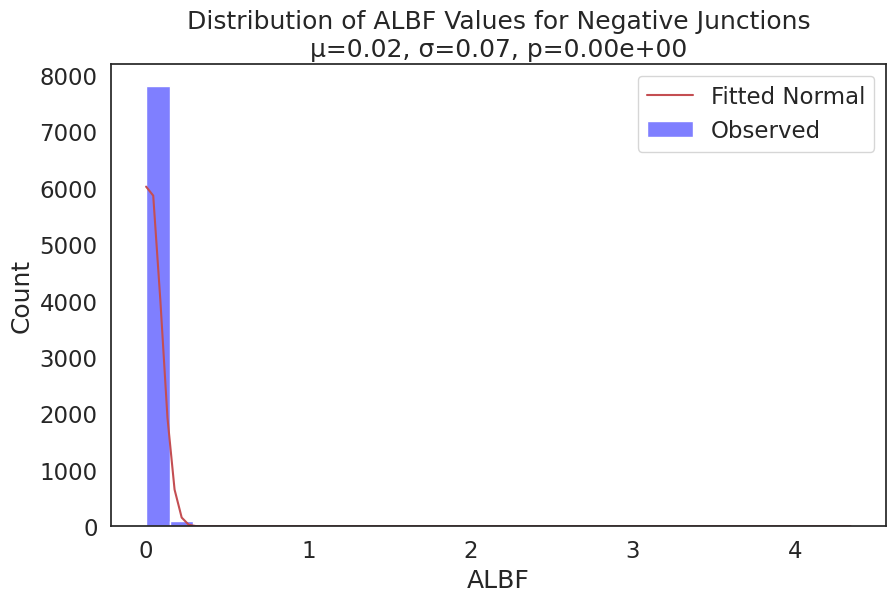

In [18]:
analyze_null_albf(albf_scores)

In [52]:
perc5=0.06838378899999997
perc1=0.2103434774

albf_scores[albf_scores["ALBF"] > perc1]["true_label"].value_counts()

true_label
positive    7551
negative      80
Name: count, dtype: int64

In [54]:
7551/(7551+80)

0.9895164460752195

In [19]:
albf_scores[(albf_scores["true_label"] == "positive") & (albf_scores["ALBF"] > 2)].shape

(6416, 10)

In [20]:
# how many negative junctions have values greater than 10 ALBF?
albf_scores[(albf_scores["true_label"] == "negative") & (albf_scores["ALBF"] > 2)].shape

(2, 10)

<Axes: xlabel='difference', ylabel='ALBF'>

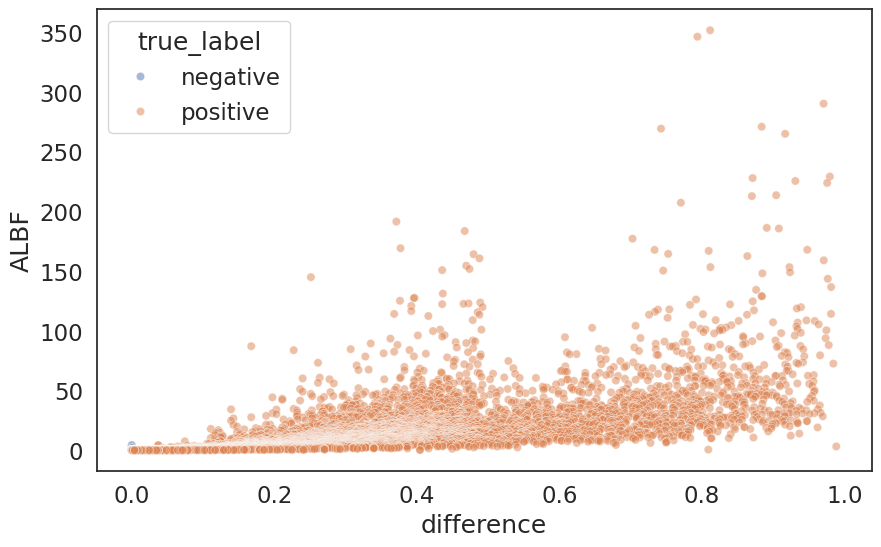

In [22]:
# let's plot difference column vs ALBF column for positive junctions under true_label
plt.figure(figsize=(10, 6))
sns.scatterplot(albf_scores, x='difference', y='ALBF', alpha=0.5, hue='true_label')

<Axes: >

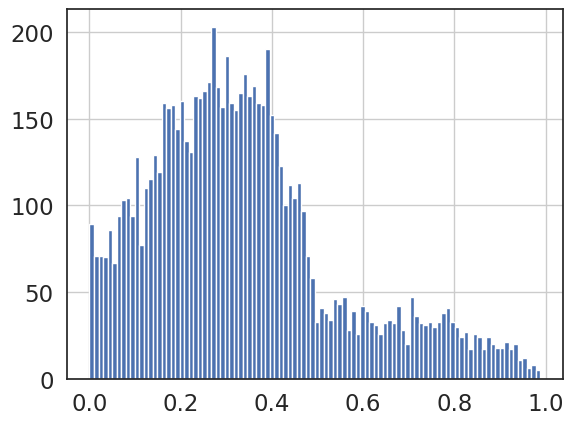

In [23]:
albf_scores[albf_scores["true_label"] == "positive"].difference.hist(bins=100)

<Axes: >

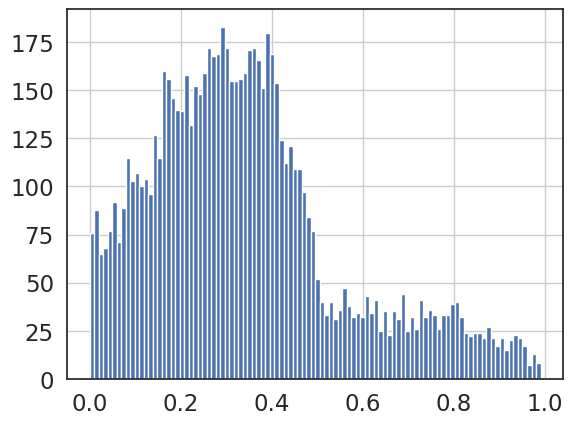

In [24]:
albf_scores[albf_scores["true_label"] == "positive"].delta_est.hist(bins=100)

In [25]:
PSI_df

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
0,0,0.121480,0.121480,0,chr10_100080130_100080856_+,negative,35178,0.000000,negative
1,1,0.757040,0.757040,1,chr10_100080130_100087346_+,negative,35178,0.000000,negative
2,2,0.121480,0.121480,2,chr10_100080940_100087346_+,negative,35178,0.000000,negative
3,0,0.000008,0.000008,3,chr10_100478022_100485050_-,negative,37286,0.000000,negative
4,1,0.999983,0.999983,4,chr10_100478022_100487161_-,negative,37286,0.000000,negative
...,...,...,...,...,...,...,...,...,...
15889,1,0.350506,0.886555,15889,chrY_898115_899427_+,positive,62094,0.536049,positive
15890,2,0.324747,0.056722,15890,chrY_898627_899427_+,positive,62094,0.268025,positive
15891,0,0.460526,0.460526,15891,chrY_900613_910447_+,negative,62095,0.000000,negative
15892,1,0.078949,0.078949,15892,chrY_910586_910656_+,negative,62095,0.000000,negative


In [31]:
# Empirical FDR = (Number of FALSE positives) / (Total number of positives)

array(['positive', 'positive', 'positive', ..., 'negative', 'negative',
       'negative'], dtype=object)

<Axes: xlabel='ALBF', ylabel='Count'>

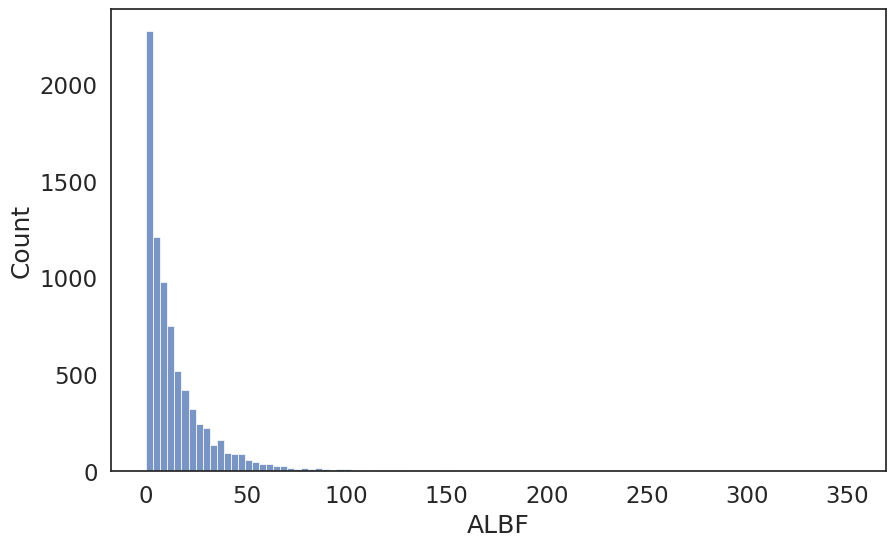

In [56]:
# plot distribution of ALBF values
plt.figure(figsize=(10, 6))
sns.histplot(data=albf_scores[albf_scores["true_label"]=="positive"], x='ALBF', bins=100, kde=False)


In [61]:
albf_scores

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label,Qvalue
9976,0.000512,0.001468,9976,4.345032,0.000000,negative,13976,0,0.000956,1,0.230148
7341,0.001468,0.000506,7341,2.292175,0.000000,negative,1676,0,0.000963,1,0.436267
6862,0.000313,0.002078,6862,1.819946,0.000000,negative,865,0,0.001765,1,0.549467
6860,0.000869,0.000394,6860,1.694458,0.000000,negative,865,0,0.000475,1,0.590159
12800,0.000578,0.001223,12800,0.823364,0.000000,negative,26609,0,0.000645,1,1.214529
...,...,...,...,...,...,...,...,...,...,...,...
6618,0.107951,0.107093,6618,0.000870,0.004271,positive,109,1,0.000858,0,1149.754355
2345,0.337619,0.343613,2345,0.000638,0.024718,positive,44551,1,0.005994,0,1566.207629
10200,0.415171,0.411618,10200,0.000297,0.007478,positive,13010,1,0.003554,0,3368.918887
13769,0.213856,0.218010,13769,0.000215,0.003699,positive,28212,1,0.004154,0,4660.337804


In [60]:
albf_scores[albf_scores["Qvalue"] < 0.05]

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label,Qvalue
7090,0.991469,0.990958,7090,-0.000004,0.000000,negative,2292,0,0.000511,0,-262143.997638
3799,0.135526,0.136620,3799,-0.000008,0.000000,negative,50291,0,0.001094,0,-131072.000537
12883,0.999329,0.999384,12883,-0.000015,0.000000,negative,25803,0,0.000055,0,-65536.000268
12007,0.001210,0.825298,12007,351.720500,0.811507,positive,21944,1,0.824088,1,0.002843
14167,0.197666,0.999267,14167,346.316100,0.793683,positive,28220,1,0.801601,1,0.002888
...,...,...,...,...,...,...,...,...,...,...,...
8808,0.454991,0.052401,8808,20.049877,0.395196,positive,7168,1,0.402591,1,0.049876
6696,0.497723,0.105533,6696,20.040134,0.381658,positive,1477,1,0.392190,1,0.049900
5245,0.880159,0.317441,5245,20.034456,0.552817,positive,55443,1,0.562718,1,0.049914
15576,0.031728,0.385095,15576,20.017923,0.347348,positive,61995,1,0.353367,1,0.049955


In [62]:
1923/15894

0.12098905247263118